# Farmer: Sample Average Approximation

How does a planting plan perform when the weather differs from the sample used to choose it?
We reuse the [farmer model](SP.ipynb), then separate training from evaluation.
This page supplies the sampling detail behind Lecture 10. All yields below are **synthetic**, not observed farm data.

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 7 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
import sys
from pathlib import Path
if "google.colab" in sys.modules:
    from urllib.request import urlretrieve
    base = "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/"
    for name in ["helper.py", "farmer.py"]:
        urlretrieve(base + name, name)
    import helper
    helper.easy_install()
else:
    sys.path.insert(0, str(Path.cwd().parent))
    import helper
import farmer as f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
helper.set_plotting_style()


## A continuous model and 20 scenarios

For scenario $s$, draw shared weather $W_s=0.65+0.70 B_s$, with $B_s\sim\mathrm{Beta}(2,2)$.
Independently draw crop deviations $E_{sc}\sim U(-0.08,0.08)$ and set
$\xi_{sc}=\bar\xi_c(W_s+E_{sc})$. Different scenarios are independent.

The population mean multiplier is one; the support is $[0.57,1.43]$. Shared weather produces positive crop dependence. These assumptions are an instructor-created illustration, not a statistical fit. The fixed seed selects 20 reproducible joint draws. Each retained draw has probability $1/20$ in the empirical model. The continuous population and its 20-point empirical approximation are different distributions.

In [2]:
scenarios = f.TWENTY
inputs = pd.DataFrame([s["yield"] for s in scenarios], index=range(1, 21))
inputs.index.name = "Scenario"
inputs["Probability"] = 1/20
display(inputs.round(4))


,WHEAT,CORN,BEETS,Probability
Scenario,,,,
1,1.8140,2.3066,15.1087,0.05
2,3.3043,3.8140,26.7994,0.05
3,2.6016,3.5153,21.9583,0.05
4,2.9580,3.3947,22.4312,0.05
5,2.2094,2.6334,17.5186,0.05
6,1.8822,2.0145,13.1005,0.05
7,2.6895,3.1978,21.5713,0.05
8,2.7908,3.0101,22.0574,0.05
9,3.3177,4.0784,25.6842,0.05


## Draw, optimize, and inspect the complete solution

For sampled yields, solve the same farmer balances with shared acreage $\mathbf{x}$:
$$\max_{\mathbf{x},\{\mathbf{y}_i\}}\frac{1}{N}\sum_{i=1}^N P(\mathbf{x},\mathbf{y}_i;\boldsymbol{\xi}_i).$$
The land constraint appears once; feed and beet balances and buying/selling decisions appear once per scenario. See the [core farmer formulation](SP.ipynb) for every constraint.

In [3]:
sampled = f.solve_farmer(f.build_farmer(f.TWENTY))
plan20 = f.plan_of(sampled)
record20 = f.evaluate_solution(plan20, f.TWENTY)


In [4]:
def show_solution(record):
    display(pd.Series(record["acreage"], name="Planted acres").to_frame().round(3))
    rows = []
    for s in record["scenarios"]:
        row = {"Scenario": s["id"], "Probability": s["probability"]}
        row.update({"Buy " + c + " (T)": v for c, v in s["purchases_tons"].items()})
        row.update({"Sell " + c + " (T)": v for c, v in s["sales_tons"].items()})
        row["Profit ($)"] = s["profit"]
        rows.append(row)
    display(pd.DataFrame(rows).set_index("Scenario").round(2))
    print(f"Expected profit: ${record['expected_profit']:,.2f}")

show_solution(record20)

,Planted acres
WHEAT,139.109
CORN,87.645
BEETS,273.246


,Probability,Buy WHEAT (T),Buy CORN (T),Sell WHEAT (T),Sell CORN (T),Sell BEETS_FAVORABLE (T),Sell BEETS_UNFAVORABLE (T),Profit ($)
Scenario,,,,,,,,
1,0.05,0.0,37.84,52.34,0.00,4128.39,0.00,37505.39
2,0.05,0.0,0.00,259.66,94.27,6000.00,1322.83,175443.51
3,0.05,0.0,0.00,161.91,68.10,6000.00,-0.00,141671.19
4,0.05,0.0,0.00,211.49,57.53,6000.00,129.22,149806.80
5,0.05,0.0,9.19,107.35,0.00,4786.87,0.00,76578.81
6,0.05,0.0,63.44,61.83,0.00,3579.66,0.00,13987.03
7,0.05,0.0,0.00,174.13,40.27,5894.26,0.00,135767.93
8,0.05,0.0,0.00,188.23,23.82,6000.00,27.08,139773.94
9,0.05,0.0,0.00,261.52,117.45,6000.00,1018.11,176187.55


Expected profit: $103,193.43


In [5]:
# Independent recourse formula checks the reported Pyomo profits.
np.testing.assert_allclose(
    [s["profit"] for s in record20["scenarios"]],
    f.analytic_profits(plan20, f.TWENTY), rtol=1e-10, atol=1e-6)


## Visualize the population and finite samples

The thin histogram uses a separate large simulation of the declared population. Dots identify the actual 20 retained scenarios. The relationship plot shows why crop yields are not independent.

In [6]:
population = f.synthetic_farmer_yields(10000, 20260928)
results = {"population": [[s["yield"][c] for c in f.CROPS] for s in population],
           "twenty": [[s["yield"][c] for c in f.CROPS] for s in f.TWENTY]}
helper.save_results("farmer-synthetic-distribution", results,
    notebook="notebooks/4-dev/Farmer_SAA.ipynb",
    description="Synthetic population draws and the fixed 20 joint yield scenarios")


[helper] wrote figures/results/farmer-synthetic-distribution.json


[helper] wrote media/figures/farmer-synthetic-distribution.png and .pdf


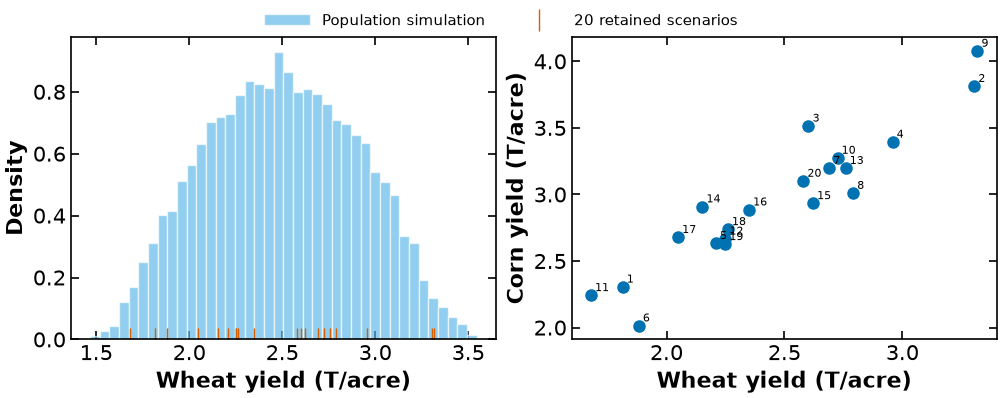

In [7]:
pop, sample = np.asarray(results["population"]), np.asarray(results["twenty"])
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
axes[0].hist(pop[:, 0], bins=40, density=True, color="#56B4E9", alpha=.65,
             edgecolor="white", label="Population simulation")
axes[0].plot(sample[:, 0], np.zeros(20), "|", color="#D55E00", ms=16,
             label="20 retained scenarios")
axes[0].set(xlabel="Wheat yield (T/acre)", ylabel="Density")
axes[1].scatter(sample[:, 0], sample[:, 1], marker="o", color="#0072B2")
axes[1].set(xlabel="Wheat yield (T/acre)", ylabel="Corn yield (T/acre)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside upper center", ncol=2, fontsize=11)
helper.save_figure(fig, "farmer-synthetic-distribution")


## Repeat the experiment as the sample size grows

For each $N$, solve 30 independently sampled training problems. Grade every selected acreage vector on the same independent set of 10,000 new harvests. The common evaluation set makes comparisons paired; it is not used to choose plans. The analytic recourse formula is checked against Pyomo above and avoids building 1.5 million evaluation Blocks.

The bands below are the 10th–90th percentiles **across training repetitions**, not confidence intervals for a true optimum. Neither an individual sequence nor every acreage coordinate must improve monotonically.

In [8]:
evaluation = f.synthetic_farmer_yields(10000, 917203)
runs = []
for n in [10, 20, 50, 100, 200]:
    for repetition in range(30):
        seed = 100000 + 1000*n + repetition
        training = f.synthetic_farmer_yields(n, seed)
        m = f.solve_farmer(f.build_farmer(training))
        acreage = f.plan_of(m)
        profits = f.analytic_profits(acreage, evaluation)
        runs.append({"N": n, "repetition": repetition, "seed": seed,
                     "acreage": acreage.tolist(),
                     "training_mean": float(f.pyo.value(m.expected_profit)),
                     "evaluation_mean": float(profits.mean()),
                     "evaluation_se": float(profits.std(ddof=1)/np.sqrt(len(profits)))})
results = {"runs": runs, "evaluation_seed": 917203, "evaluation_n": 10000,
           "fixed20": record20,
           "inputs20": [s["yield"] for s in f.TWENTY]}
helper.save_results("farmer-saa-convergence", results,
    notebook="notebooks/4-dev/Farmer_SAA.ipynb", solver="appsi_highs",
    description="30 independent training repetitions per N; common independent evaluation")
display(pd.DataFrame(runs).groupby("N")[["training_mean", "evaluation_mean"]].mean().round(2))


[helper] wrote figures/results/farmer-saa-convergence.json


,training_mean,evaluation_mean
N,,
10,109700.78,108035.32
20,108310.86,108366.43
50,110284.15,108520.51
100,109726.73,108553.46
200,108925.04,108575.55


[helper] wrote media/figures/farmer-saa-convergence.png and .pdf


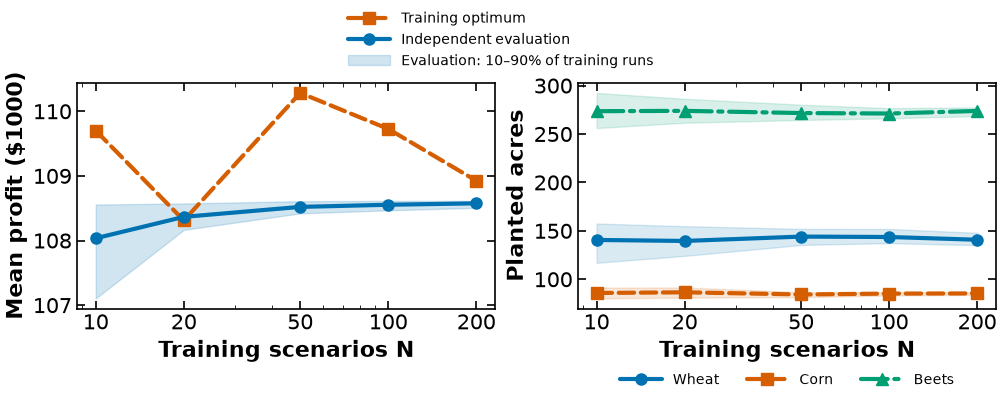

In [9]:
runs = results["runs"]
ns = sorted({r["N"] for r in runs})
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for key, label, color, marker, style in [
    ("training_mean", "Training optimum", "#D55E00", "s", "--"),
    ("evaluation_mean", "Independent evaluation", "#0072B2", "o", "-")]:
    groups = [np.array([r[key] for r in runs if r["N"] == n])/1000 for n in ns]
    axes[0].plot(ns, [g.mean() for g in groups], color=color, marker=marker,
                 linestyle=style, label=label)
    if key == "evaluation_mean":
        axes[0].fill_between(ns, [np.quantile(g,.1) for g in groups],
                            [np.quantile(g,.9) for g in groups], color=color, alpha=.18,
                            label="Evaluation: 10–90% of training runs")
for j, (label, color, marker) in enumerate(zip(
    ["Wheat", "Corn", "Beets"], ["#0072B2", "#D55E00", "#009E73"], ["o","s","^"])):
    groups = [np.array([r["acreage"][j] for r in runs if r["N"] == n]) for n in ns]
    axes[1].plot(ns, [g.mean() for g in groups], color=color, marker=marker, label=label)
    axes[1].fill_between(ns, [np.quantile(g,.1) for g in groups],
                        [np.quantile(g,.9) for g in groups], color=color, alpha=.15)
axes[0].set(xlabel="Training scenarios N", ylabel="Mean profit ($1000)")
axes[1].set(xlabel="Training scenarios N", ylabel="Planted acres")
for ax in axes: ax.set_xscale("log"); ax.set_xticks(ns, labels=ns)
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside upper center", ncol=1, fontsize=10)
axes[1].legend(loc="upper center", bbox_to_anchor=(.5,-.23), ncol=3, fontsize=10)
helper.save_figure(fig, "farmer-saa-convergence")


## Interpreting sampling uncertainty

For a fixed trained plan, the independent evaluation mean estimates its population expected profit under the synthetic generator. Its standard error is $s_P/\sqrt{M}$, not the standard deviation of one year's profit. Increasing evaluation size improves the estimate, not the acreage decision.

For maximization, the sample optimum is optimistic **in expectation**:
$$\mathbb E[\max_x\widehat P_N(x)]\ge\max_x\mathbb E[P(x,\Xi)].$$
A particular sample may still give a smaller value. Policy evaluation alone is not an optimality-gap certificate. Replicated sampled optima and independent candidate evaluation can support statistical bounds, subject to their assumptions. See [Advanced Topics](AdvancedTopics.ipynb) for the detailed construction and quadrature comparison.

Bootstrapping the original 20 observations approximates uncertainty conditional on their empirical distribution; it does not create new population information. Fresh draws in this experiment come from the declared continuous model.

**Primary references:** Mak, Morton & Wood (1999), *Monte Carlo bounding techniques for determining solution quality in stochastic programs*, §2, [DOI](https://doi.org/10.1016/S0167-6377(98)00054-6); Bayraksan & Morton (2006), *Assessing solution quality in stochastic programs*, [DOI](https://doi.org/10.1007/s10107-006-0720-x). Source locators and numerical checks are maintained with the lecture audit.

## Same population, a fresh sample

These empirical cumulative distributions use two independent sets of 20 harvests from the same generator. The staircases differ because the retained harvests differ. The population model did not change. Both sets preserve the within-scenario association between crop yields; the plot sorts each marginal only for display.

In [10]:
fresh = f.synthetic_farmer_yields(20, 20260929)
fresh_model = f.solve_farmer(f.build_farmer(fresh))
results = {"original": [[s["yield"][c] for c in f.CROPS] for s in f.TWENTY],
           "fresh": [[s["yield"][c] for c in f.CROPS] for s in fresh],
           "original_acres": plan20.tolist(), "fresh_acres": f.plan_of(fresh_model).tolist(),
           "seeds": [f.SYNTHETIC_SEED, 20260929]}
helper.save_results("farmer-fresh-samples", results,
    notebook="notebooks/4-dev/Farmer_SAA.ipynb",solver="appsi_highs",
    description="Two independent 20-harvest empirical distributions and their optimal acreage")
display(pd.DataFrame([plan20, f.plan_of(fresh_model)], columns=f.CROPS,
                     index=["Original 20", "Fresh 20"]).round(2))


[helper] wrote figures/results/farmer-fresh-samples.json


,WHEAT,CORN,BEETS
Original 20,139.11,87.64,273.25
Fresh 20,150.21,81.31,268.48


[helper] wrote media/figures/farmer-fresh-samples.png and .pdf


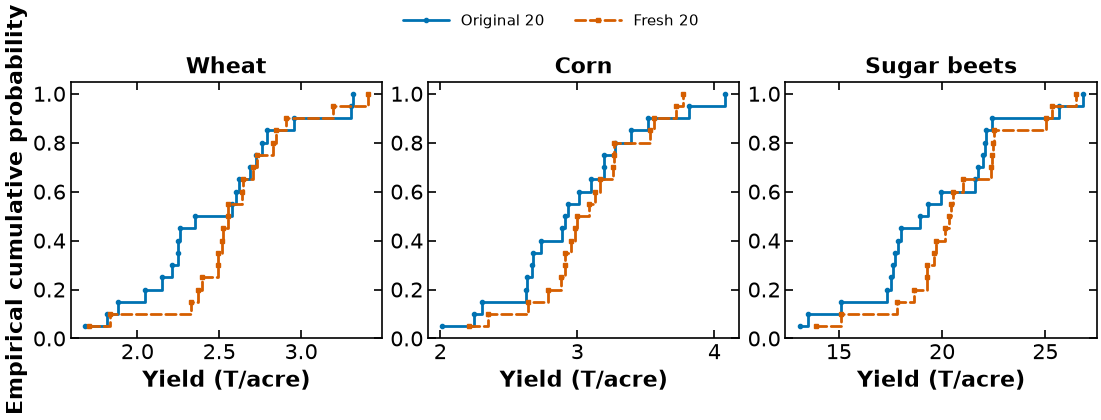

In [11]:
fig,axes=plt.subplots(1,3,figsize=(11,3.8),layout="constrained")
for j,crop in enumerate(["Wheat","Corn","Sugar beets"]):
    for key,label,color,style,marker in [
        ("original","Original 20","#0072B2","-","o"),
        ("fresh","Fresh 20","#D55E00","--","s")]:
        x=np.sort(np.asarray(results[key])[:,j])
        axes[j].step(x,np.arange(1,21)/20,where="post",color=color,
                     linestyle=style,marker=marker,ms=3,linewidth=2,label=label)
    axes[j].set(title=crop,xlabel="Yield (T/acre)",ylim=(0,1.05))
axes[0].set_ylabel("Empirical cumulative probability")
fig.legend(*axes[0].get_legend_handles_labels(),loc="outside upper center",ncol=2,fontsize=11)
helper.save_figure(fig,"farmer-fresh-samples")
